# Stage 4 — EDA on Acoustic Features

## Acoustic Feature Extraction and Analysis

We analyse acoustic features from processed audio, compare real vs. fake statistically, and assess discriminative power and redundancy.

**Pipeline order:** After 03 (EDA on Raw Audio). Requires: `python scripts/run_preprocessing.py` then `python scripts/extract_features.py`. This notebook reads from `data/features/acoustic_features.csv`.

## 1. Setup and Load Data

In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

PROJECT_ROOT = Path("..")
sys.path.insert(0, str(PROJECT_ROOT))

from config import FEATURES_DIR

In [ ]:
# Load features (requires: run_preprocessing.py, then extract_features.py)
feat_path = FEATURES_DIR / "acoustic_features.csv"
if not feat_path.exists():
    raise FileNotFoundError(
        "Run first: python scripts/run_preprocessing.py && python scripts/extract_features.py"
    )
df = pd.read_csv(feat_path)

X = df.drop(columns=["path", "label"])
y = df["label"]
feature_names = list(X.columns)

print(f"Samples: {len(df)}, Features: {len(feature_names)}")
print(f"Class distribution: Real={sum(y==0)}, Fake={sum(y==1)}")

Samples: 4311, Features: 118
Class distribution: Real=2274, Fake=2037


### 1.1 Class Balance

A balanced dataset supports unbiased model training. Severe imbalance may require stratified sampling or cost-sensitive learning.

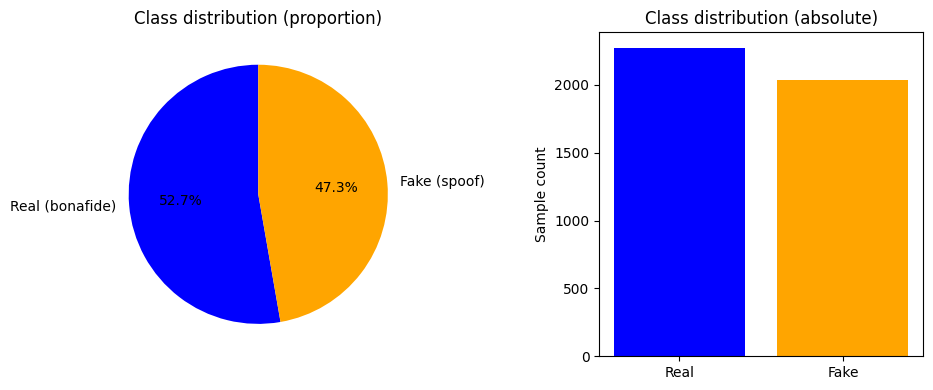

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
# Pie chart
counts = [sum(y == 0), sum(y == 1)]
axes[0].pie(counts, labels=["Real (bonafide)", "Fake (spoof)"], autopct="%1.1f%%", colors=["blue", "orange"], startangle=90)
axes[0].set_title("Class distribution (proportion)")
# Bar chart
axes[1].bar(["Real", "Fake"], counts, color=["blue", "orange"])
axes[1].set_ylabel("Sample count")
axes[1].set_title("Class distribution (absolute)")
for ax in axes:
    ax.set_box_aspect(1)
plt.tight_layout()
plt.show()

**What we learn:** A ratio around 1.1 (real/fake) indicates near-balanced classes. No severe imbalance; standard stratified splits and macro F1 are appropriate. If the ratio were >3 or <0.33, we would consider oversampling, class weights, or SMOTE.

## 2. Feature Definitions and Physical Meaning

| Feature | Mathematical Definition | Physical Meaning | Why AI May Differ |
|---------|-------------------------|------------------|--------------------|
| **MFCCs 1–13** | DCT of log-mel filterbank | Perceptual spectral envelope | Vocoder artifacts, over-smooth spectra |
| **Delta MFCCs** | Frame-to-frame MFCC derivative | Temporal dynamics | TTS may have smoother trajectories |
| **Delta-delta MFCCs** | Second derivative | Prosody, acceleration | Synthetic often more regular |
| **Spectral Flux** | Frame-to-frame L2 norm of spectral change | Dynamic variation | TTS often more static |
| **F0 Jitter** | Relative cycle-to-cycle F0 variation | Vocal-fold micro-variability | Synthetic voices often more regular |
| **Spectral Rolloff** | Freq. below which 85% energy lies | High-frequency content | Vocoder roll-off differences |
| **Spectral Centroid** | Frequency center of mass | Brightness | Synthetic may differ in high-freq balance |
| **HNR** | Harmonic-to-noise ratio | Periodicity vs. noise | Vocoder noise characteristics |
| **RMS Energy** | Root-mean-square amplitude | Loudness | Compression/level artifacts |
| **Spectral Bandwidth** | Centroid-based spread | Spectral dispersion | Narrower bands in synthetic |
| **ZCR** | Zero-crossing rate | High-frequency content | Quantization/artifact differences |
| **Temporal Spectral Flux** | Std of spectral flux over time | Long-term dynamics | Less natural variation in TTS |
| **Chromagram** | Pitch-class distribution | Musical/harmonic content | Different harmonic structure |

## 3. Statistical Comparison (Real vs. Fake)

In [ ]:
def compare_feature(df, col, label_col="label"):
    real = df[df[label_col] == 0][col].dropna()
    fake = df[df[label_col] == 1][col].dropna()
    stat, p = stats.mannwhitneyu(real, fake, alternative="two-sided")
    # Cohen's d
    d = (np.mean(real) - np.mean(fake)) / (np.sqrt((np.std(real)**2 + np.std(fake)**2) / 2) + 1e-8)
    return {"u_stat": stat, "p_value": p, "cohens_d": d, "real_mean": real.mean(), "fake_mean": fake.mean()}

results = []
for col in feature_names:
    r = compare_feature(df, col)
    r["feature"] = col
    results.append(r)

stats_df = pd.DataFrame(results)
stats_df = stats_df.sort_values("p_value")
stats_df

,u_stat,p_value,cohens_d,real_mean,fake_mean,feature
106,1304991.0,1.384750e-135,-0.758956,0.305164,0.344818,chroma_std_1
103,1473967.0,1.182757e-94,-0.678491,0.018595,0.029318,chroma_mean_10
14,1533816.0,6.130381e-82,-0.675311,13.136994,15.123975,mfcc_std_2
90,1563317.5,5.151466e-76,-0.557742,681.583061,763.883981,spectral_bandwidth_std
88,1568095.0,4.467206e-75,-0.565750,0.073035,0.084270,rms_std
...,...,...,...,...,...,...
47,2303475.5,7.575751e-01,-0.085128,1.499135,1.521444,mfcc_delta_std_9
32,2322521.0,8.743133e-01,-0.022846,0.001822,0.002360,mfcc_delta_mean_7
29,2314463.0,9.686003e-01,-0.023563,-0.001278,-0.000348,mfcc_delta_mean_4
92,2317242.0,9.770727e-01,0.047731,0.157706,0.155510,zcr_std


**What we learn from the statistical table:**
- **p_value < 0.05** indicates a significant difference between real and fake for that feature; lower p means stronger evidence.
- **Cohen's d** measures effect size: |d| < 0.2 = small, 0.2–0.8 = medium, > 0.8 = large. Large |d| suggests the feature is a strong candidate for classification.
- **real_mean vs fake_mean** shows direction: e.g. higher spectral_bandwidth_std in fake may reflect vocoder artifacts.

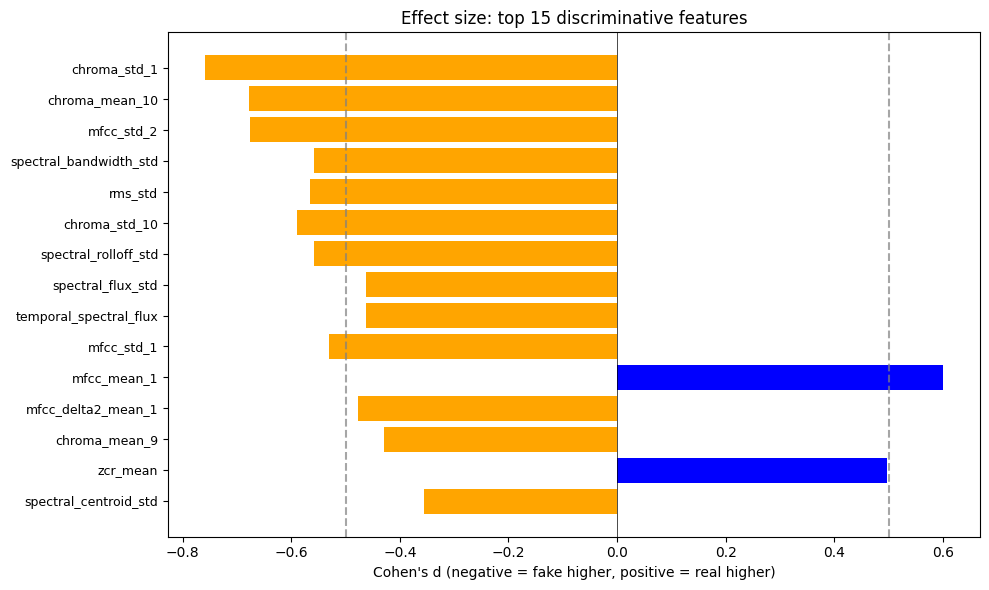

In [ ]:
# Effect size (Cohen's d) - magnitude of real vs fake difference
top_stats = stats_df.nsmallest(15, "p_value")
fig, ax = plt.subplots(figsize=(10, 6))
colors = ["orange" if d < 0 else "blue" for d in top_stats["cohens_d"]]
ax.barh(range(len(top_stats)), top_stats["cohens_d"], color=colors)
ax.set_yticks(range(len(top_stats)))
ax.set_yticklabels(top_stats["feature"], fontsize=9)
ax.set_xlabel("Cohen's d (negative = fake higher, positive = real higher)")
ax.set_title("Effect size: top 15 discriminative features")
ax.axvline(0, color="black", linewidth=0.5)
ax.axvline(-0.5, color="gray", linestyle="--", alpha=0.7, label="medium effect")
ax.axvline(0.5, color="gray", linestyle="--", alpha=0.7)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 3.2 Distribution comparison (violin plots)

Violin plots show the full distribution of each feature by class. Overlap indicates weaker discriminative power; separated distributions suggest the feature helps distinguish real from fake.

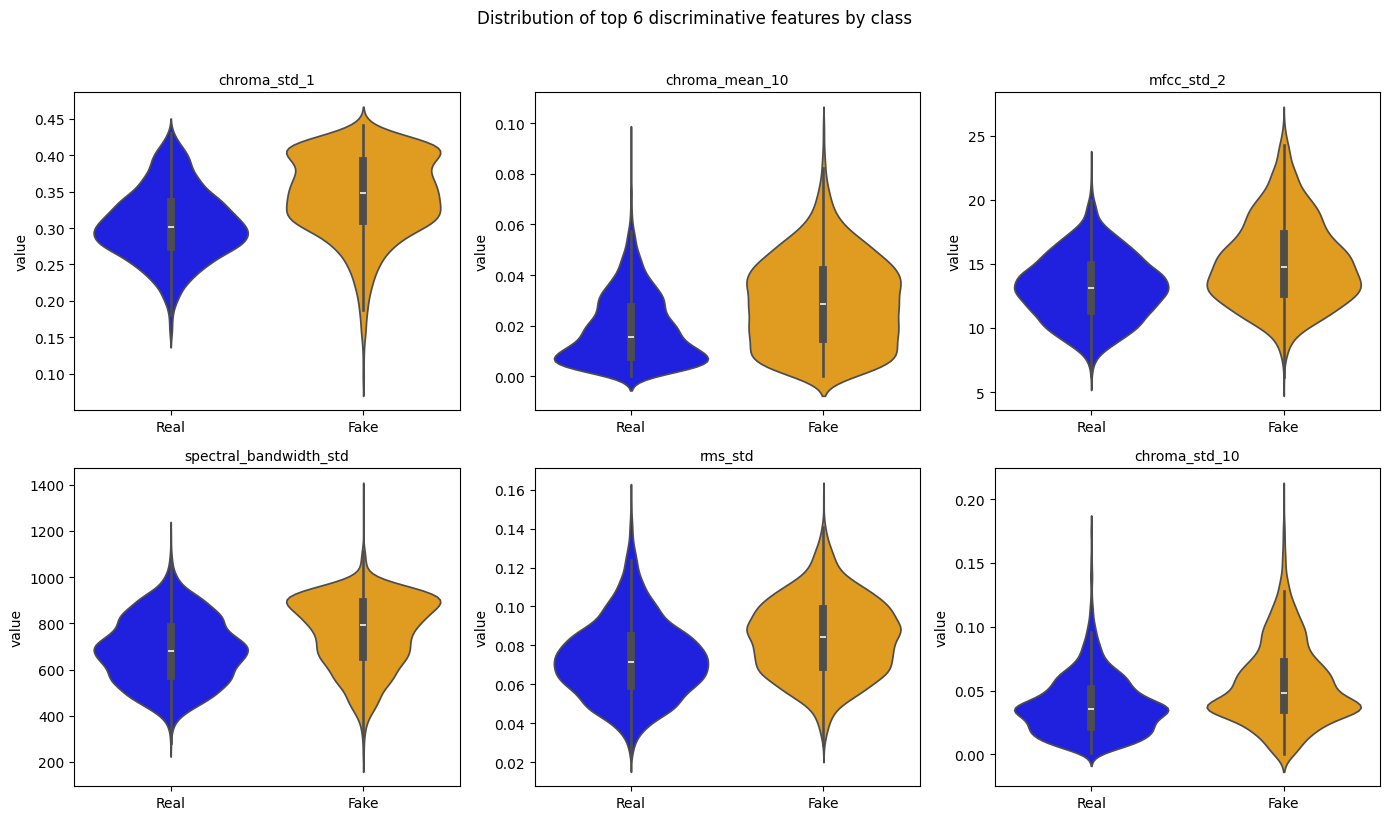

In [ ]:
# Violin plots for top 6 discriminative features
top6 = top_stats["feature"].head(6).tolist()
df_plot = df[["label"] + top6].copy()
df_plot["label"] = df_plot["label"].map({0: "Real", 1: "Fake"})
df_long = df_plot.melt(id_vars="label", var_name="feature", value_name="value")

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for i, feat in enumerate(top6):
    sub = df_long[df_long["feature"] == feat]
    sns.violinplot(data=sub, x="label", y="value", hue="label", palette={"Real": "blue", "Fake": "orange"}, legend=False, ax=axes[i])
    axes[i].set_title(feat, fontsize=10)
    axes[i].set_xlabel("")
plt.suptitle("Distribution of top 6 discriminative features by class", y=1.02)
plt.tight_layout()
plt.show()

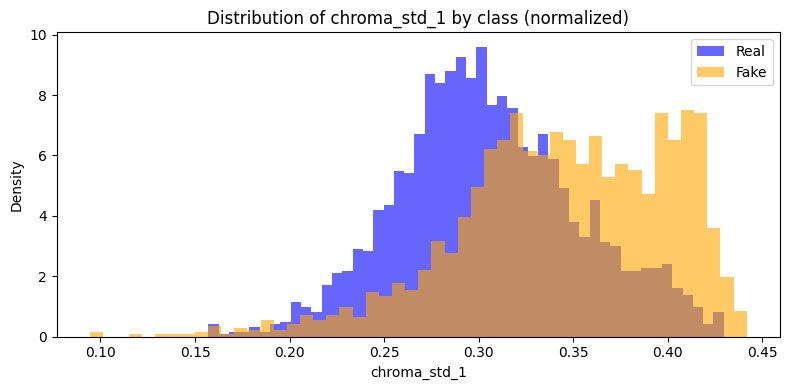

In [ ]:
# Histogram overlay: distribution of top feature by class
top_feat = top6[0]
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df[df["label"] == 0][top_feat].dropna(), bins=50, alpha=0.6, label="Real", color="blue", density=True)
ax.hist(df[df["label"] == 1][top_feat].dropna(), bins=50, alpha=0.6, label="Fake", color="orange", density=True)
ax.set_xlabel(top_feat)
ax.set_ylabel("Density")
ax.set_title(f"Distribution of {top_feat} by class (normalized)")
ax.legend()
plt.tight_layout()
plt.show()

**What we learn:** Overlapping histograms show class overlap; the degree of separation indicates how well this feature alone could classify. A feature with clearly separated peaks would achieve high AUC; broad overlap suggests we need multiple features.

## 4. Discriminative Power (AUC per feature)

In [ ]:
auc_scores = []
for col in feature_names:
    try:
        auc = roc_auc_score(y, df[col].fillna(df[col].median()))
        auc_scores.append({"feature": col, "auc": auc})
    except Exception:
        auc_scores.append({"feature": col, "auc": 0.5})

auc_df = pd.DataFrame(auc_scores).sort_values("auc", ascending=False)
auc_df

,feature,auc
106,chroma_std_1,0.718275
103,chroma_mean_10,0.681796
14,mfcc_std_2,0.668875
90,spectral_bandwidth_std,0.662506
88,rms_std,0.661475
...,...,...
25,mfcc_std_13,0.422437
54,mfcc_delta2_mean_3,0.421682
112,chroma_std_7,0.415427
91,zcr_mean,0.371054


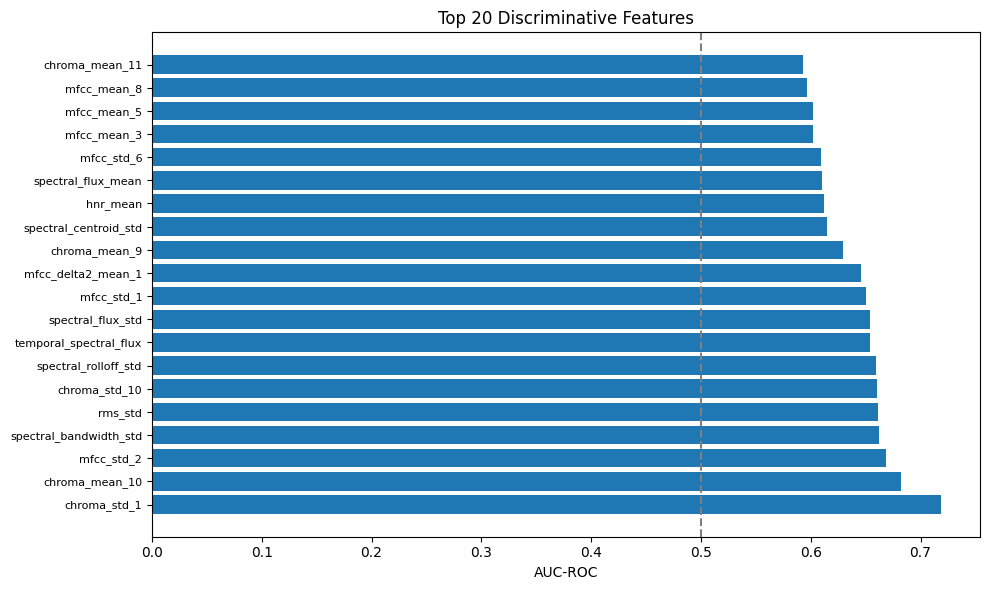

In [ ]:
plt.figure(figsize=(10, 6))
top_auc = auc_df.head(20)
plt.barh(range(len(top_auc)), top_auc["auc"])
plt.yticks(range(len(top_auc)), top_auc["feature"], fontsize=8)
plt.xlabel("AUC-ROC")
plt.title("Top 20 Discriminative Features")
plt.axvline(0.5, color="gray", linestyle="--")
plt.tight_layout()
plt.show()

**What we learn from the AUC chart:**
- **AUC = 0.5** means random guessing; AUC > 0.5 indicates the feature helps predict the class.
- Features with AUC > 0.55 are useful; AUC > 0.6 suggests strong discriminative power.
- No single feature reaches very high AUC (e.g. 0.9), so combining multiple features is expected to improve performance.

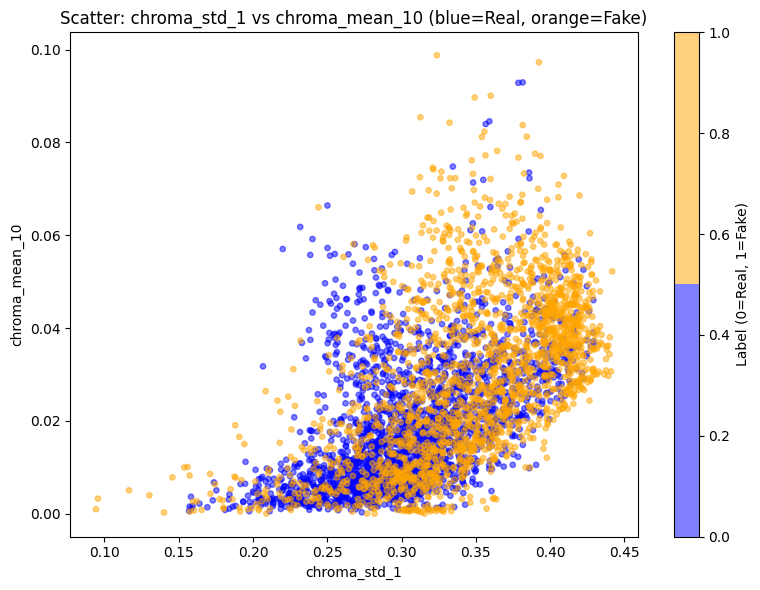

In [ ]:
# Pairwise scatter: two top features (real vs fake)
top2 = auc_df.head(2)["feature"].tolist()
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(df[top2[0]], df[top2[1]], c=df["label"], cmap=ListedColormap(['blue', 'orange']), alpha=0.5, s=15)
ax.set_xlabel(top2[0])
ax.set_ylabel(top2[1])
ax.set_title(f"Scatter: {top2[0]} vs {top2[1]} (blue=Real, orange=Fake)")
plt.colorbar(scatter, label="Label (0=Real, 1=Fake)")
plt.tight_layout()
plt.show()

**What we learn from the scatter:** Overlapping point clouds indicate that two features alone cannot perfectly separate classes; a classifier will need to combine many features. If clusters were well separated, a simple linear boundary might suffice.

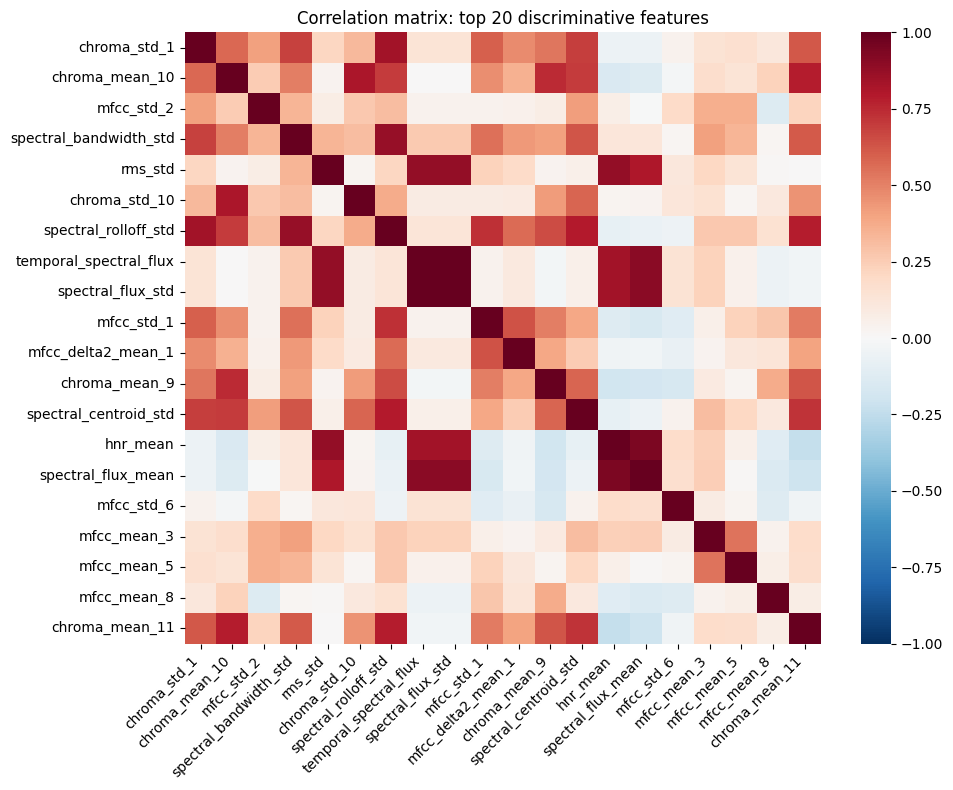

In [ ]:
# Zoomed correlation: top 20 discriminative features (readable labels)
top20_feats = auc_df.head(20)["feature"].tolist()
corr_top = X[top20_feats].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_top, cmap="RdBu_r", center=0, vmin=-1, vmax=1, annot=False, xticklabels=True, yticklabels=True, fmt=".1f")
plt.title("Correlation matrix: top 20 discriminative features")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**What we learn from the correlation matrix:**
- **Bright red/blue** = high positive or negative correlation; correlated features carry overlapping information.
- **MFCCs** often correlate with each other (they share a spectral basis); delta and delta-delta add temporal info.
- **High correlation** suggests redundancy—PCA or feature selection can reduce dimensions without losing much information.

## 5. Correlation Matrix and Redundancy

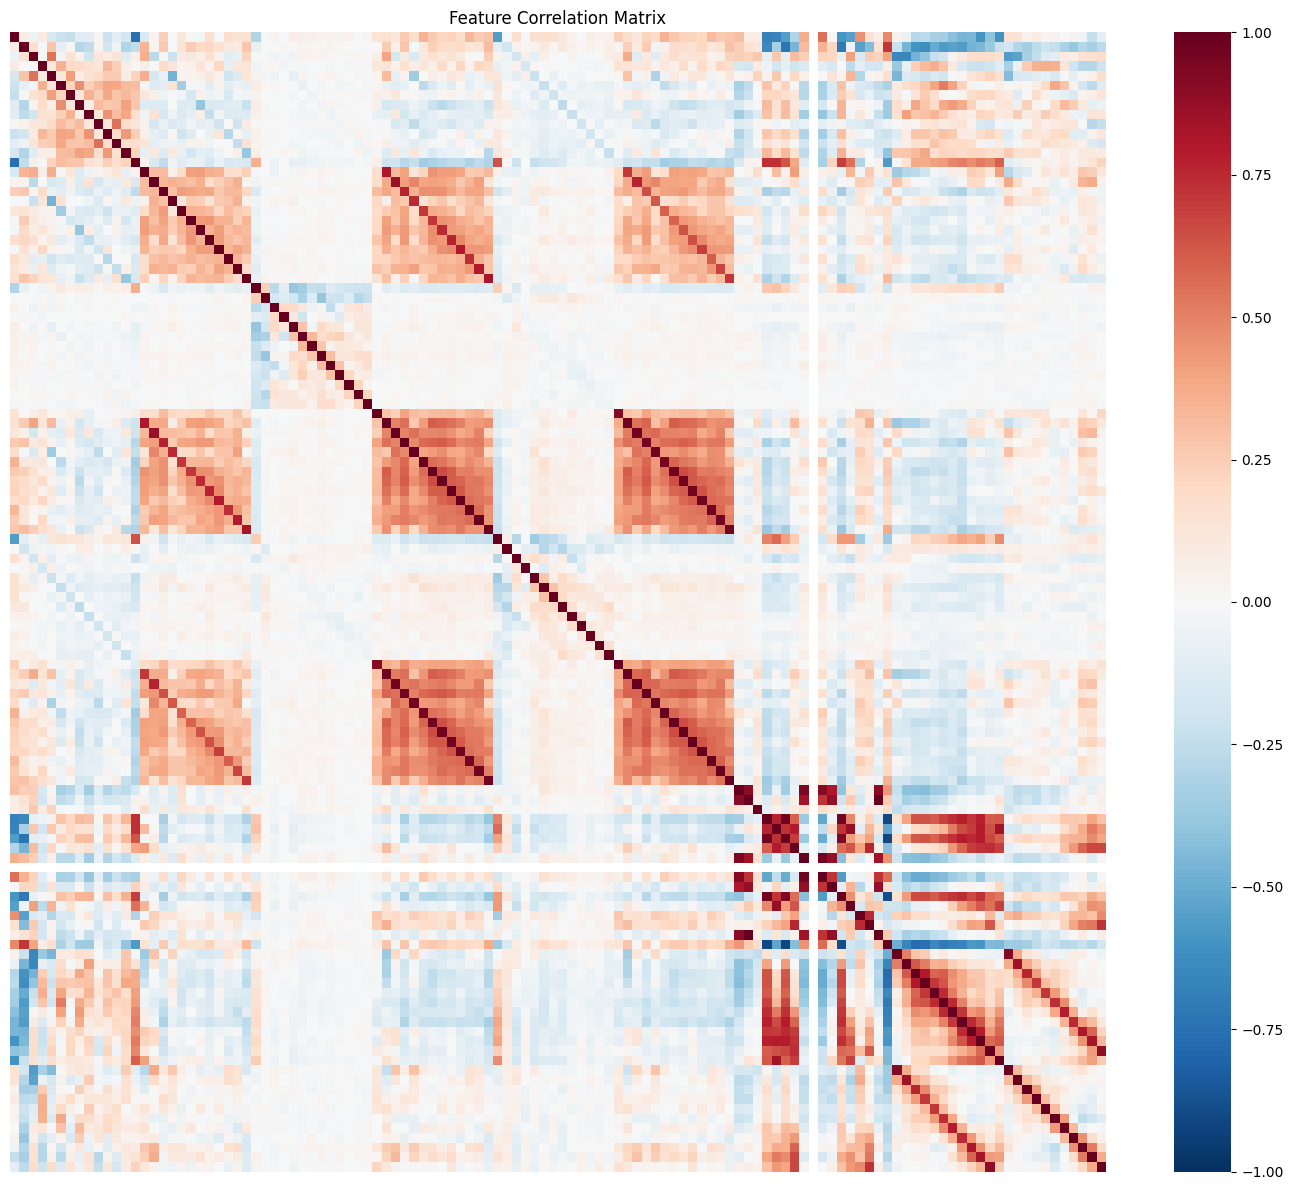

In [ ]:
corr = X.corr()
plt.figure(figsize=(14, 12))
sns.heatmap(corr, cmap="RdBu_r", center=0, vmin=-1, vmax=1, xticklabels=False, yticklabels=False)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

**What we learn from PCA:**
- **Number of components for 95% variance** indicates effective dimensionality; if much smaller than 118, many features are redundant.
- **Steep drop** in the first few bars means a few PCs capture most variance; later components add diminishing returns.

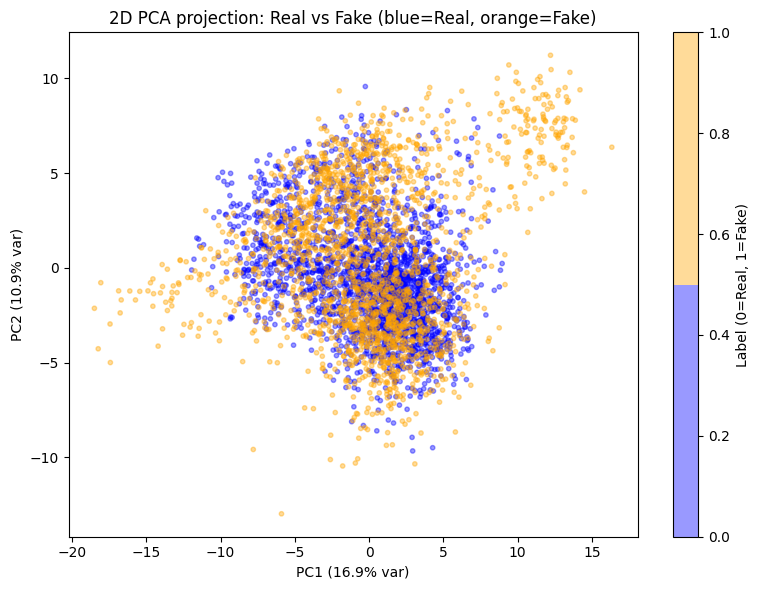

In [ ]:
# 2D PCA projection (first two PCs) colored by class
X_scaled = StandardScaler().fit_transform(X.fillna(X.median()))
pca2 = PCA(n_components=2)
X_pca = pca2.fit_transform(X_scaled)
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap=ListedColormap(['blue', 'orange']), alpha=0.4, s=10)
ax.set_xlabel(f"PC1 ({100*pca2.explained_variance_ratio_[0]:.1f}% var)")
ax.set_ylabel(f"PC2 ({100*pca2.explained_variance_ratio_[1]:.1f}% var)")
ax.set_title("2D PCA projection: Real vs Fake (blue=Real, orange=Fake)")
plt.colorbar(scatter, label="Label (0=Real, 1=Fake)")
plt.tight_layout()
plt.show()

**What we learn from 2D PCA:** If real and fake form distinct clusters, the first two PCs capture class-separating structure. Overlap indicates that higher-dimensional structure (more PCs or original features) is needed for discrimination. This motivates using all features or a learned representation (e.g. deep networks) rather than just 2D PCA.

Components explaining 95% variance: 59
Original features: 118


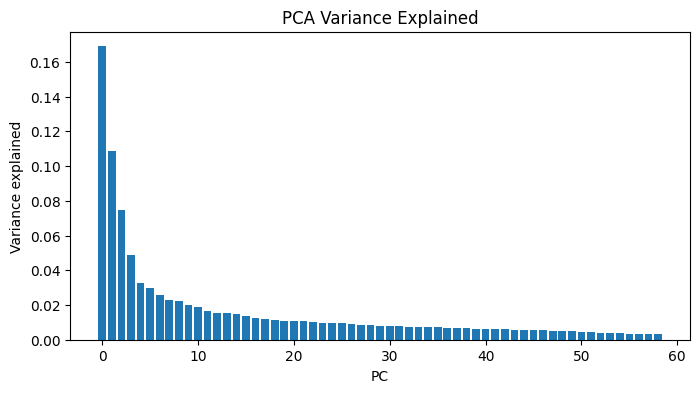

In [ ]:
# PCA to assess redundancy
X_scaled = StandardScaler().fit_transform(X.fillna(X.median()))
pca = PCA(n_components=0.95)
pca.fit(X_scaled)
print(f"Components explaining 95% variance: {pca.n_components_}")
print(f"Original features: {X.shape[1]}")
plt.figure(figsize=(8, 4))
plt.bar(range(len(pca.explained_variance_ratio_)), pca.explained_variance_ratio_)
plt.xlabel("PC")
plt.ylabel("Variance explained")
plt.title("PCA Variance Explained")
plt.show()

## 6. MFCC Heatmap (sample real vs. fake)

**What we learn from MFCC heatmaps:**
- **Rows** = MFCC coefficients (1–13); **x-axis** = time.
- **Smooth horizontal bands** in synthetic audio may indicate over-smooth spectra from vocoders.
- **More variation over time** in real speech reflects natural prosody; synthetic may show more uniform patterns or periodic artifacts. Compare the texture and dynamics between real and fake samples.

## 7. Forensic-Style Analyses (from eda_ml)

Additional analyses inspired by forensic audio detection: spectral centroid (brightness), rolloff (high-freq content), HNR (signal purity), jitter vs shimmer (vocal micro-variability), ZCR, and energy volatility. These complement the earlier statistical comparisons with domain-specific visualizations.

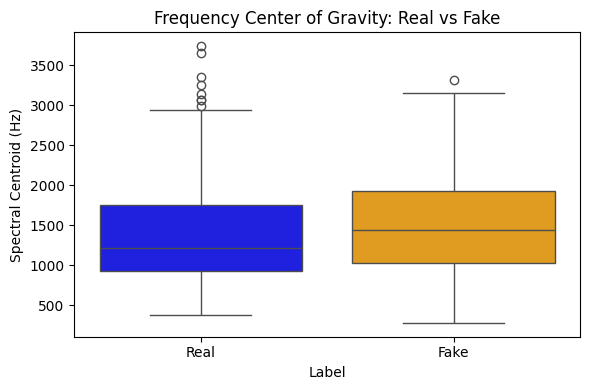

In [ ]:
# Spectral Centroid (frequency center of gravity) - Real vs Fake
df_cent = df[["label", "spectral_centroid_mean"]].copy()
df_cent["Label"] = df_cent["label"].map({0: "Real", 1: "Fake"})
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=df_cent, x="Label", y="spectral_centroid_mean", hue="Label", palette={"Real": "blue", "Fake": "orange"}, legend=False)
ax.set_ylabel("Spectral Centroid (Hz)")
ax.set_title("Frequency Center of Gravity: Real vs Fake")
plt.tight_layout()
plt.show()

**What we learn:** Spectral centroid reflects perceptual brightness. Synthetic speech may have different high-frequency balance due to vocoder design; real human speech typically shows more natural variation in spectral centroid.

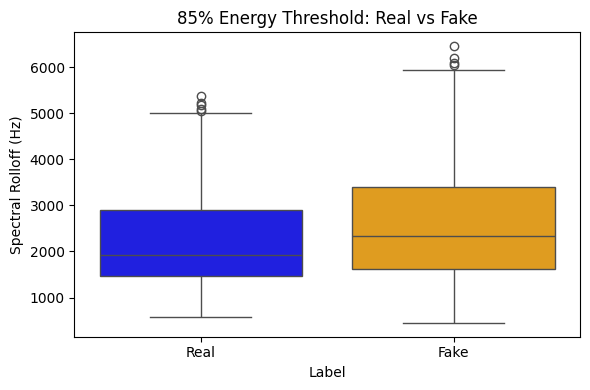

In [ ]:
# Spectral Rolloff (85% energy threshold) - Real vs Fake
df_roll = df[["label", "spectral_rolloff_mean"]].copy()
df_roll["Label"] = df_roll["label"].map({0: "Real", 1: "Fake"})
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=df_roll, x="Label", y="spectral_rolloff_mean", hue="Label", palette={"Real": "blue", "Fake": "orange"}, legend=False)
ax.set_ylabel("Spectral Rolloff (Hz)")
ax.set_title("85% Energy Threshold: Real vs Fake")
plt.tight_layout()
plt.show()

**What we learn:** Rolloff indicates how much high-frequency content is present. Vocoders often have different roll-off characteristics than natural speech; synthetic audio may show systematically higher or lower rolloff depending on the TTS model.

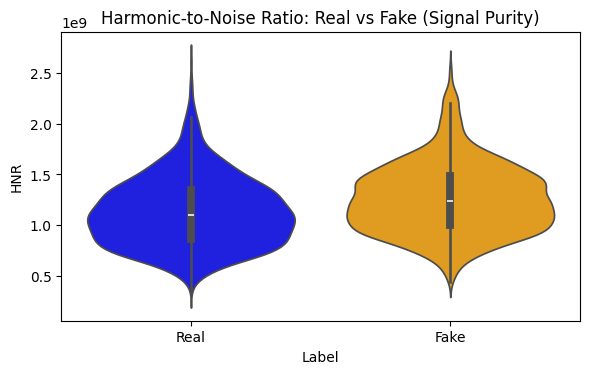

In [ ]:
# HNR (Harmonic-to-Noise Ratio) - Real vs Fake
df_hnr = df[["label", "hnr_mean"]].copy()
df_hnr["Label"] = df_hnr["label"].map({0: "Real", 1: "Fake"})
fig, ax = plt.subplots(figsize=(6, 4))
sns.violinplot(data=df_hnr, x="Label", y="hnr_mean", hue="Label", palette={"Real": "blue", "Fake": "orange"}, legend=False)
ax.set_ylabel("HNR")
ax.set_title("Harmonic-to-Noise Ratio: Real vs Fake (Signal Purity)")
plt.tight_layout()
plt.show()

**What we learn:** HNR measures periodicity vs. noise. Natural speech has characteristic harmonic structure; synthetic vocoders may produce different harmonic/noise balance, often cleaner (higher HNR) or with artifacts (lower HNR in some models).

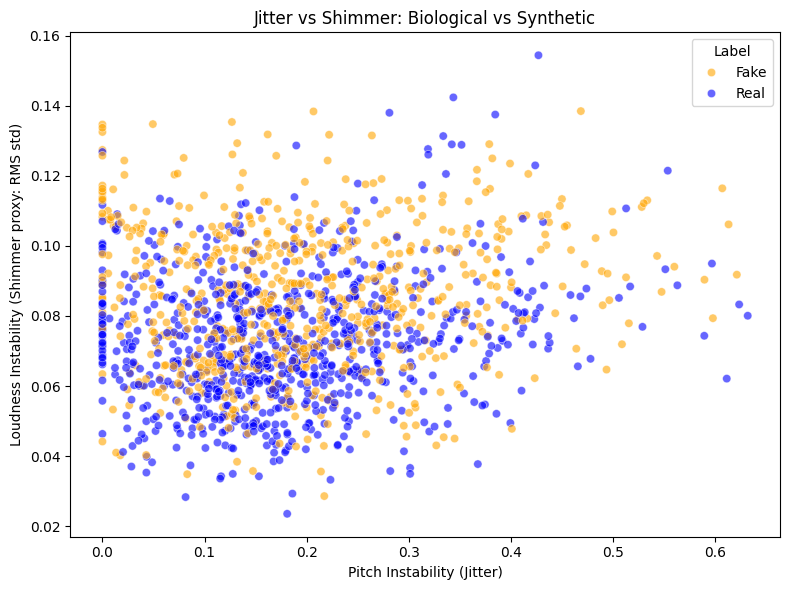

In [ ]:
# Jitter vs Shimmer (vocal micro-variability) - Biological vs Synthetic
# Jitter = f0_jitter (pitch instability), Shimmer proxy = rms_std (loudness instability)
df_jit = df[["label", "f0_jitter", "rms_std"]].copy()
df_jit["Label"] = df_jit["label"].map({0: "Real", 1: "Fake"})
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=df_jit.sample(min(1500, len(df_jit)), random_state=42), x="f0_jitter", y="rms_std", hue="Label", palette={"Real": "blue", "Fake": "orange"}, alpha=0.6)
ax.set_xlabel("Pitch Instability (Jitter)")
ax.set_ylabel("Loudness Instability (Shimmer proxy: RMS std)")
ax.set_title("Jitter vs Shimmer: Biological vs Synthetic")
plt.tight_layout()
plt.show()

**What we learn:** Natural human voice exhibits micro-variations in pitch (jitter) and amplitude (shimmer). Synthetic speech is often more regular. If real and fake occupy different regions in this space, both features contribute to discrimination.

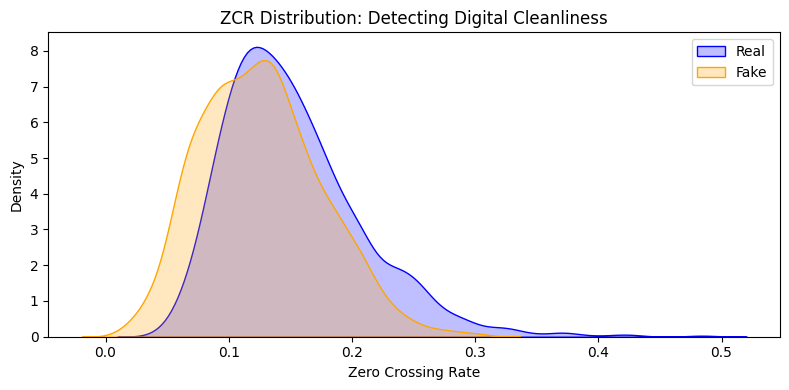

In [ ]:
# Zero Crossing Rate - Real vs Fake (KDE)
fig, ax = plt.subplots(figsize=(8, 4))
sns.kdeplot(data=df[df["label"]==0]["zcr_mean"], label="Real", fill=True, color="blue")
sns.kdeplot(data=df[df["label"]==1]["zcr_mean"], label="Fake", fill=True, color="orange")
ax.set_xlabel("Zero Crossing Rate")
ax.set_ylabel("Density")
ax.set_title("ZCR Distribution: Detecting Digital Cleanliness")
ax.legend()
plt.tight_layout()
plt.show()

**What we learn:** ZCR reflects high-frequency content and noisiness. Synthetic audio may have different ZCR profiles due to vocoder quantization or filtering; overlapping distributions suggest ZCR alone is weakly discriminative but may help in combination.

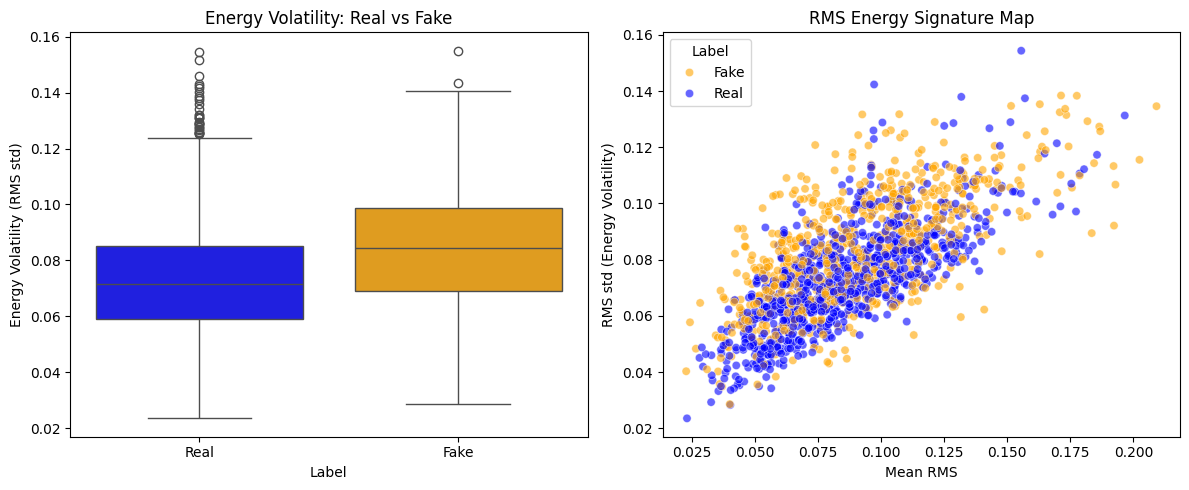

In [ ]:
# Energy Volatility (RMS std) and RMS scatter - Natural vs Synthetic
df_rms = df[["label", "rms_mean", "rms_std"]].copy()
df_rms["Label"] = df_rms["label"].map({0: "Real", 1: "Fake"})
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df_rms, x="Label", y="rms_std", hue="Label", palette={"Real": "blue", "Fake": "orange"}, legend=False, ax=axes[0])
axes[0].set_ylabel("Energy Volatility (RMS std)")
axes[0].set_title("Energy Volatility: Real vs Fake")
sns.scatterplot(data=df_rms.sample(min(1500, len(df_rms)), random_state=42), x="rms_mean", y="rms_std", hue="Label", palette={"Real": "blue", "Fake": "orange"}, alpha=0.6, ax=axes[1])
axes[1].set_xlabel("Mean RMS")
axes[1].set_ylabel("RMS std (Energy Volatility)")
axes[1].set_title("RMS Energy Signature Map")
plt.tight_layout()
plt.show()

**What we learn:** Natural speech has more variable energy dynamics; synthetic may be more uniform. The scatter plot shows whether real and fake form distinct clusters in (mean RMS, volatility) space.

### Spectral Bandwidth (Real vs Fake)

Spectral bandwidth measures the spread of the spectrum around the centroid. TTS/vocoder models often produce narrower or differently shaped spectral bands than natural speech.

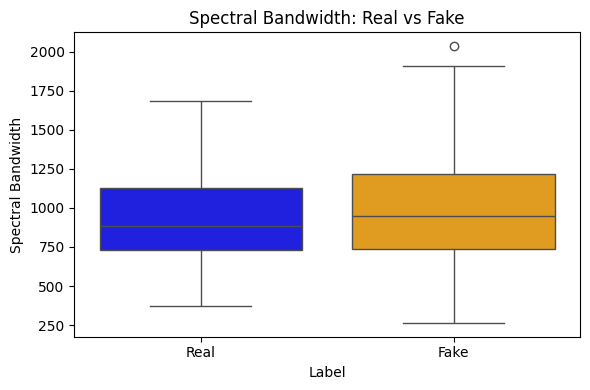

In [ ]:
# Spectral Bandwidth boxplot
df_bw = df[["label", "spectral_bandwidth_mean"]].copy()
df_bw["Label"] = df_bw["label"].map({0: "Real", 1: "Fake"})
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=df_bw, x="Label", y="spectral_bandwidth_mean", hue="Label", palette={"Real": "blue", "Fake": "orange"}, legend=False)
ax.set_ylabel("Spectral Bandwidth")
ax.set_title("Spectral Bandwidth: Real vs Fake")
plt.tight_layout()
plt.show()

### Spectral Centroid vs Rolloff (2D scatter)

A 2D projection using two key forensic features: spectral centroid (brightness) and rolloff (high-frequency cutoff). Overlapping clusters indicate features alone may not separate classes; combined with others they can still help.

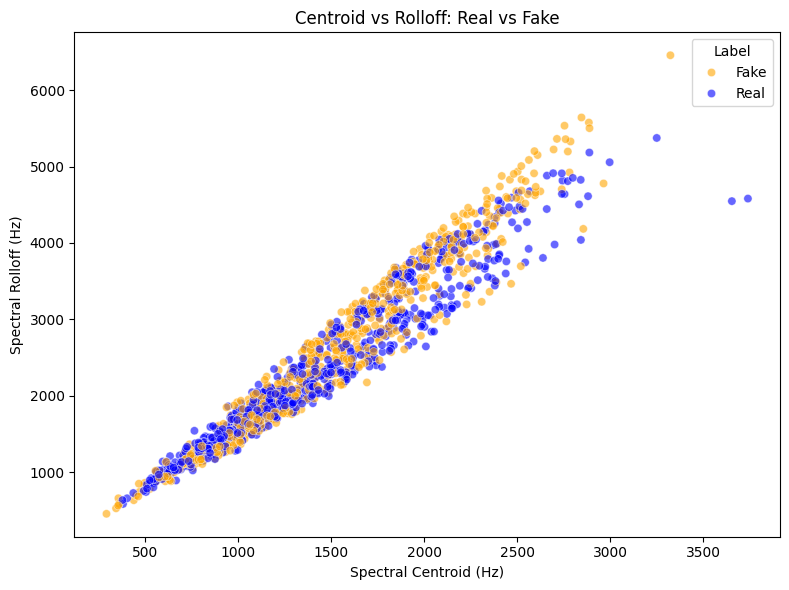

In [ ]:
# Centroid vs Rolloff scatter (subsample for visibility)
df_cr = df[["label", "spectral_centroid_mean", "spectral_rolloff_mean"]].copy()
df_cr["Label"] = df_cr["label"].map({0: "Real", 1: "Fake"})
sub = df_cr.sample(min(1500, len(df_cr)), random_state=42)
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=sub, x="spectral_centroid_mean", y="spectral_rolloff_mean", hue="Label", palette={"Real": "blue", "Fake": "orange"}, alpha=0.6)
ax.set_xlabel("Spectral Centroid (Hz)")
ax.set_ylabel("Spectral Rolloff (Hz)")
ax.set_title("Centroid vs Rolloff: Real vs Fake")
plt.tight_layout()
plt.show()

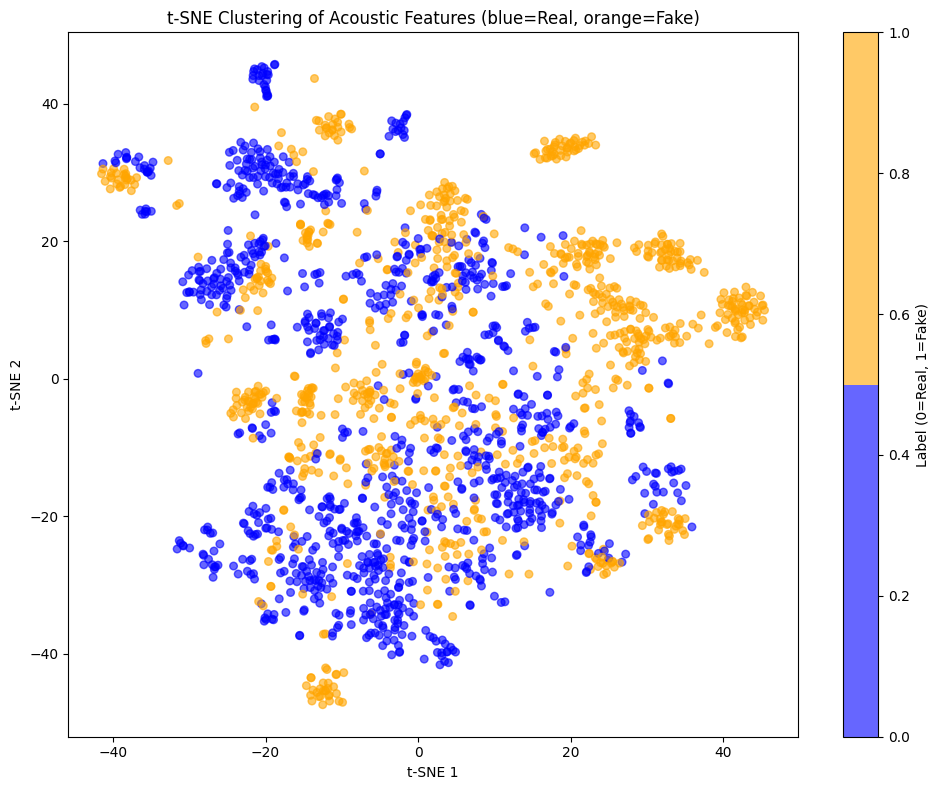

In [ ]:
# t-SNE: Non-linear embedding of features (subsample for speed)
from sklearn.manifold import TSNE
X_sc = StandardScaler().fit_transform(X.fillna(X.median()))
n_tsne = min(2000, len(X))
idx = np.random.RandomState(42).choice(len(X), n_tsne, replace=False)
X_sub = X_sc[idx]
y_sub = y.values[idx]
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X_sub)
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_sub, cmap=ListedColormap(['blue', 'orange']), alpha=0.6, s=30)
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_title("t-SNE Clustering of Acoustic Features (blue=Real, orange=Fake)")
plt.colorbar(scatter, label="Label (0=Real, 1=Fake)")
plt.tight_layout()
plt.show()

**What we learn:** t-SNE reveals non-linear structure. If real and fake form distinct clusters, the feature set captures class-separating structure. Overlap indicates the problem is challenging and that classifiers must learn complex decision boundaries. t-SNE can also reveal sub-clusters (e.g. different TTS models within fake).

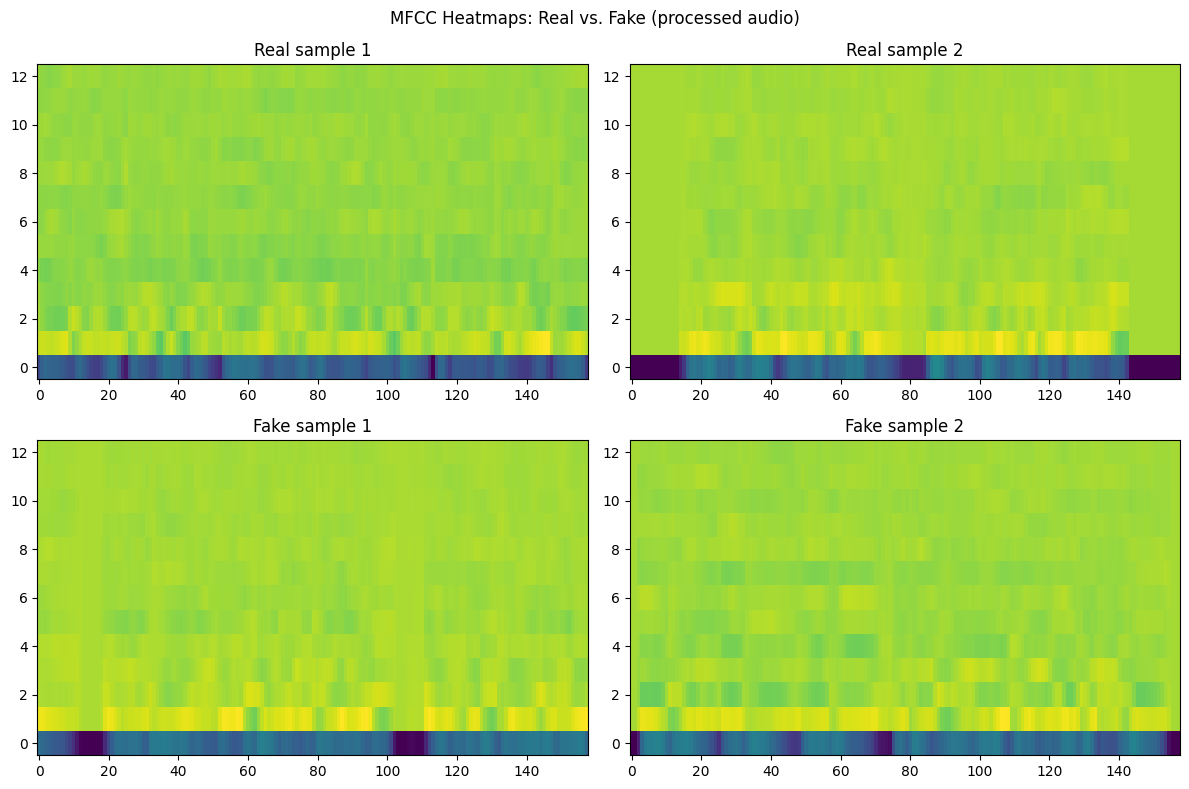

In [ ]:
from src.features.acoustic_scipy import extract_all_features
from src.utils.audio import load_audio
from config import PROCESSED_DIR, SAMPLE_RATE
from src.utils.paths import get_audio_paths_with_labels

pairs = get_audio_paths_with_labels(PROCESSED_DIR)
real_paths = [p for p, l in pairs if l == 0][:2]
fake_paths = [p for p, l in pairs if l == 1][:2]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i, path in enumerate(real_paths):
    y = load_audio(path, sr=SAMPLE_RATE)
    feat = extract_all_features(y, sr=SAMPLE_RATE, include_raw=True)
    axes[0, i].imshow(feat["mfcc_2d"].T, aspect="auto", origin="lower")
    axes[0, i].set_title(f"Real sample {i+1}")
for i, path in enumerate(fake_paths):
    y = load_audio(path, sr=SAMPLE_RATE)
    feat = extract_all_features(y, sr=SAMPLE_RATE, include_raw=True)
    axes[1, i].imshow(feat["mfcc_2d"].T, aspect="auto", origin="lower")
    axes[1, i].set_title(f"Fake sample {i+1}")
plt.suptitle("MFCC Heatmaps: Real vs. Fake (processed audio)")
plt.tight_layout()
plt.show()

## 8. Chromagram Comparison

**What we learn from chromagrams:**
- **Rows** = pitch classes (C, C#, D, …); **x-axis** = time.
- Chroma captures harmonic structure. **Different patterns** between real and fake may reflect vocoder artifacts or synthetic harmonic generation.
- Strong vertical stripes can indicate pitch stability; more diffuse patterns may reflect natural pitch variation or noise.

### EDA Takeaways

1. **Class balance** — Dataset is nearly balanced; standard evaluation metrics are appropriate.
2. **Top discriminative features** — MFCC std, spectral bandwidth/rolloff std, RMS std; variance-related features distinguish real from fake.
3. **Effect size** — Several features show medium effect (|Cohen's d| 0.5–0.7); no single feature dominates.
4. **Redundancy** — PCA suggests many features are correlated; dimensionality reduction or regularized models may help.
5. **2D separability** — Overlap in 2D PCA implies higher-dimensional or nonlinear models (RF, CNN, transformers) are needed.
6. **Time–frequency patterns** — MFCC and chroma heatmaps can reveal textural differences; useful for CNN or attention-based models.

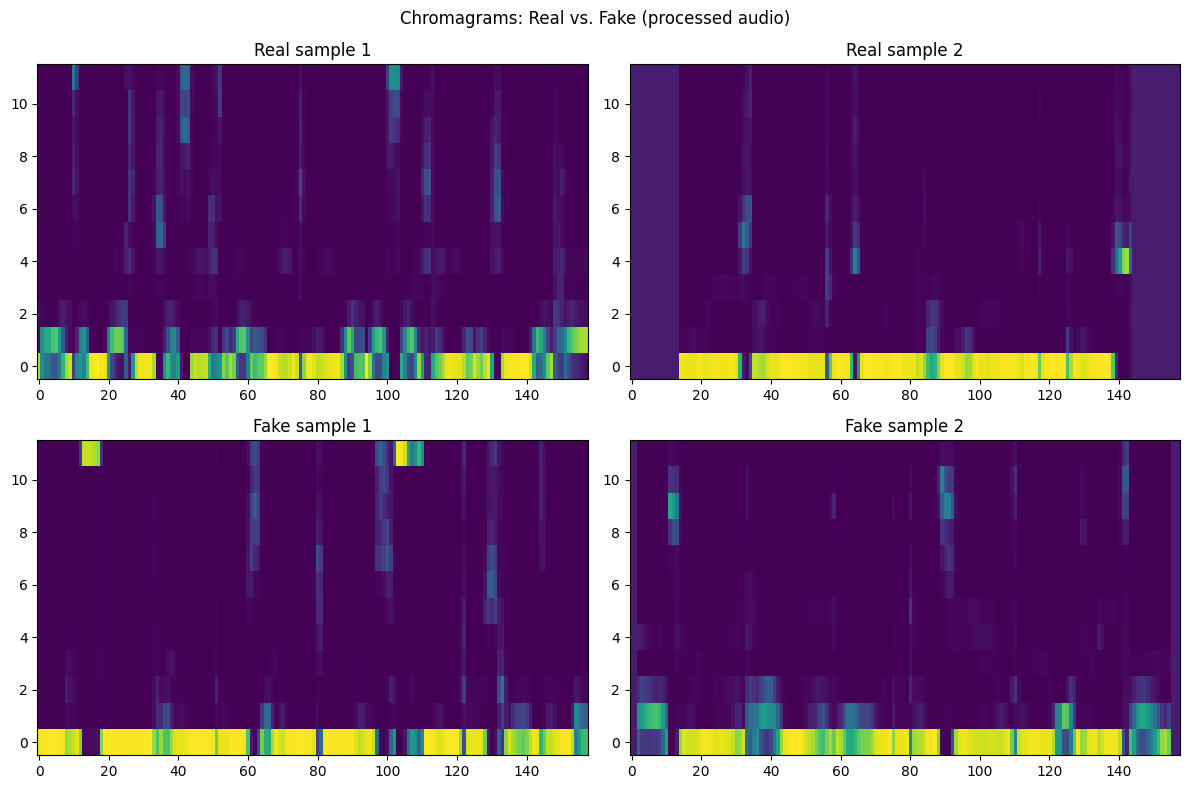

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i, path in enumerate(real_paths):
    y = load_audio(path, sr=SAMPLE_RATE)
    feat = extract_all_features(y, sr=SAMPLE_RATE, include_raw=True)
    axes[0, i].imshow(feat["chroma_2d"].T, aspect="auto", origin="lower")
    axes[0, i].set_title(f"Real sample {i+1}")
for i, path in enumerate(fake_paths):
    y = load_audio(path, sr=SAMPLE_RATE)
    feat = extract_all_features(y, sr=SAMPLE_RATE, include_raw=True)
    axes[1, i].imshow(feat["chroma_2d"].T, aspect="auto", origin="lower")
    axes[1, i].set_title(f"Fake sample {i+1}")
plt.suptitle("Chromagrams: Real vs. Fake (processed audio)")
plt.tight_layout()
plt.show()

## 9. Summary

Features such as MFCCs, spectral flux, and chroma are derived from overlapping spectral representations and thus exhibit correlation. PCA shows how many effective dimensions capture the variance. High correlation between features suggests redundancy; low correlation suggests complementary information. The optional classical baseline (optional_classical_baseline.ipynb) will use all features; feature importance will reveal which contribute most. The forensic-style analyses (section 7) add domain-specific perspectives from audio deepfake detection research.